In [1]:
import os
import sys
import yaml
import pandas as pd
import numpy as np

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']

sys.path.append(os.path.join(LOCAL_PATH, "src/python"))

import writing_tools as wt

from matplotlib import pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

os.environ['LOKY_MAX_CPU_COUNT'] = '1' # because of windows core count warning

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)
with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']
DATA_PATH = local_config['DATA_PATH']
EMBEDDING_DIMENSION = config['EMBEDDING_DIMENSION']

rng = np.random.default_rng(12898)

N_CLUSTERS = 3
N_COMPONENTS = 10

In [2]:
meetings_df = pd.read_csv(os.path.join(DATA_PATH, "intermediate_data/cpc/meetings-manifest.csv"))

agenda_df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "agenda_items.parquet"))

docs_df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "supplemental_docs.parquet"))

df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "analysis_data_w_embeddings.parquet"))

In [3]:
# Basic info

NUMBER_OF_MEETINGS = meetings_df['date'].nunique()
FIRST_MEETING_DATE = pd.to_datetime(meetings_df['date']).min()
LAST_MEETING_DATE = pd.to_datetime(meetings_df['date']).max()
NUMBER_OF_YEARS = LAST_MEETING_DATE.year - FIRST_MEETING_DATE.year + 1
NUMBER_OF_CASES = len(df)

RESULTS = {
    "NumberOfMeetings": f"{NUMBER_OF_MEETINGS}",
    "FirstMeetingDate": FIRST_MEETING_DATE.strftime('%Y-%m-%d'),
    "LastMeetingDate": LAST_MEETING_DATE.strftime('%Y-%m-%d'),
    "NumberOfYears": f"{NUMBER_OF_YEARS}",
    "NumberOfCases": f"{NUMBER_OF_CASES:,.0f}"
}

_ = wt.update_results(RESULTS)
RESULTS


{'NumberOfMeetings': '175',
 'FirstMeetingDate': '2018-05-10',
 'LastMeetingDate': '2026-02-26',
 'NumberOfYears': '9',
 'NumberOfCases': '818'}

In [4]:
# Number of agenda items (total, including non-cases)

AGENDA_ITEMS = len(agenda_df)

RESULTS = {
    "NumberOfAgendaItems": f"{AGENDA_ITEMS:,.0f}"
}

_ = wt.update_results(RESULTS)
RESULTS

{'NumberOfAgendaItems': '1,730'}

In [5]:
# Number of (usable) supplemental documents

SUPPLEMENTAL_DOCS = len(docs_df)

RESULTS = {
    "NumberOfSupplementalDocs": f"{SUPPLEMENTAL_DOCS:,.0f}"
}

_ = wt.update_results(RESULTS)
RESULTS


{'NumberOfSupplementalDocs': '5,874'}

In [6]:
# Page counts

PAGE_COUNT = meetings_df["agenda_pages"].sum() + meetings_df["minutes_pages"].sum() + meetings_df["supdocs_pages"].sum()
RESULTS = {
    "PageCount": f"{PAGE_COUNT:,.0f}"
}
_ = wt.update_results(RESULTS)
RESULTS
    

{'PageCount': '29,131'}

In [7]:
df['project_result'].fillna('na').value_counts()

project_result
APPROVED                                           354
APPROVED WITH MINOR CONDITIONS OR MODIFICATIONS    298
DELAYED                                            122
APPROVED WITH MAJOR CONDITIONS OR MODIFICATIONS     30
DENIED                                              10
APPLICATION WITHDRAWN                                4
Name: count, dtype: int64

In [8]:
# Motion results vs. unanimity

df['unanimity'] = ''
df.loc[ df['num_noes']==0, 'unanimity'] = 'Unanimous'
df.loc[ df['num_noes']==1, 'unanimity'] = '1 Nay'
df.loc[ df['num_noes']>1, 'unanimity'] = '>1 Nays'

header = r"""
\begin{table}[H]
\caption{Summary of Motion Outcomes and Vote Results}
\vspace{0.2cm}
\label{tab_result_unanimity}
\begin{adjustbox}{max width=\textwidth}
\begin{threeparttable}
\begin{tabular}{lrrrrr} \toprule
 & \multicolumn{3}{c}{Unanimity} & & \\
 Project Implication & Unanimous & 1 Nay & >1 Nays & Total &  \\ \midrule
 """
footer = r"""
\bottomrule
\end{tabular}
\begin{tablenotes}
\item {\textit{Notes: } This table shows the number of cases decided on by the City Planning Commission, organized by the implication of the motion for the project proposal and the unanimity of the vote.}
\end{tablenotes}
\end{threeparttable}
\end{adjustbox}
\end{table}
"""
tbl = ""

# Approved
tbl += " ~ ~ Approved"
mask = df['project_result'] == 'APPROVED'
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Approved with minor conditions
tbl += " ~ ~ Approved with minor conditions"
mask = df['project_result'] == 'APPROVED WITH MINOR CONDITIONS OR MODIFICATIONS'
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Approved with major conditions
tbl += " ~ ~ Approved with major conditions"
mask = df['project_result'] == 'APPROVED WITH MAJOR CONDITIONS OR MODIFICATIONS'
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Deliberations continued
tbl += " ~ ~ Deliberations continued to future date"
mask = df['project_result'].isin(['DELAYED'])
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Denied
tbl += " ~ ~ Denied or withdrawn"
mask = df['project_result'].isin(['DENIED', 'APPLICATION WITHDRAWN'])
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df.loc[mask, 'unanimity']==u).sum():,.0f}"
tbl += f" & {mask.sum():,.0f}"
tbl += f" & ({mask.sum()/len(df)*100:.1f}\\%) \\\\ [1ex]\n"

# Total
tbl += "TOTAL"
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & {(df['unanimity']==u).sum():,.0f}"
tbl += f" & {len(df):,.0f}"
tbl += f" & \\\\ [1ex]\n"

# Percents
tbl += ""
for u in ["Unanimous", "1 Nay", ">1 Nays"]:
    tbl += f" & ({(df['unanimity']==u).sum()/len(df)*100:.1f}\\%)"
tbl += " & & \\\\ [1ex] "

print(header + tbl + footer)

with open(os.path.join(LOCAL_PATH, "tables", "tab_result_unanimity.tex"), "w", encoding='utf-8') as f:
    f.write(header + tbl + footer)



\begin{table}[H]
\caption{Summary of Motion Outcomes and Vote Results}
\vspace{0.2cm}
\label{tab_result_unanimity}
\begin{adjustbox}{max width=\textwidth}
\begin{threeparttable}
\begin{tabular}{lrrrrr} \toprule
 & \multicolumn{3}{c}{Unanimity} & & \\
 Project Implication & Unanimous & 1 Nay & >1 Nays & Total &  \\ \midrule
  ~ ~ Approved & 333 & 17 & 4 & 354 & (43.3\%) \\ [1ex]
 ~ ~ Approved with minor conditions & 265 & 21 & 12 & 298 & (36.4\%) \\ [1ex]
 ~ ~ Approved with major conditions & 23 & 2 & 5 & 30 & (3.7\%) \\ [1ex]
 ~ ~ Deliberations continued to future date & 119 & 3 & 0 & 122 & (14.9\%) \\ [1ex]
 ~ ~ Denied or withdrawn & 11 & 1 & 2 & 14 & (1.7\%) \\ [1ex]
TOTAL & 751 & 44 & 23 & 818 & \\ [1ex]
 & (91.8\%) & (5.4\%) & (2.8\%) & & \\ [1ex] 
\bottomrule
\end{tabular}
\begin{tablenotes}
\item {\textit{Notes: } This table shows the number of cases decided on by the City Planning Commission, organized by the implication of the motion for the project proposal and the unanimity 

In [9]:
CasesDeniedPct = f"{(df['project_result'].isin(['DENIED', 'APPLICATION WITHDRAWN'])).mean()*100:.1f}"
CasesContinued = f"{(df['project_result'].isin(['DELAYED'])).sum():,.0f}"
CasesContinuedPct = f"{(df['project_result'].isin(['DELAYED'])).mean()*100:.1f}"
CasesApprovedPct = f"{(df['project_result']=='APPROVED').mean()*100:.1f}"
CasesApprovedMinorPct = f"{(df['project_result']=='APPROVED WITH MINOR CONDITIONS OR MODIFICATIONS').mean()*100:.1f}"
CasesApprovedMajorPct = f"{(df['project_result']=='APPROVED WITH MAJOR CONDITIONS OR MODIFICATIONS').mean()*100:.1f}"
CasesUnanimousPct = f"{(df['unanimity']=='Unanimous').mean()*100:.1f}"

RESULTS = {
    "CasesDeniedPct": CasesDeniedPct,
    "CasesContinued": CasesContinued,
    "CasesContinuedPct": CasesContinuedPct,
    "CasesApprovedPct": CasesApprovedPct,
    "CasesApprovedMinorPct": CasesApprovedMinorPct,
    "CasesApprovedMajorPct": CasesApprovedMajorPct,
    "CasesUnanimousPct": CasesUnanimousPct
}

_ = wt.update_results(RESULTS)
RESULTS


{'CasesDeniedPct': '1.7',
 'CasesContinued': '122',
 'CasesContinuedPct': '14.9',
 'CasesApprovedPct': '43.3',
 'CasesApprovedMinorPct': '36.4',
 'CasesApprovedMajorPct': '3.7',
 'CasesUnanimousPct': '91.8'}

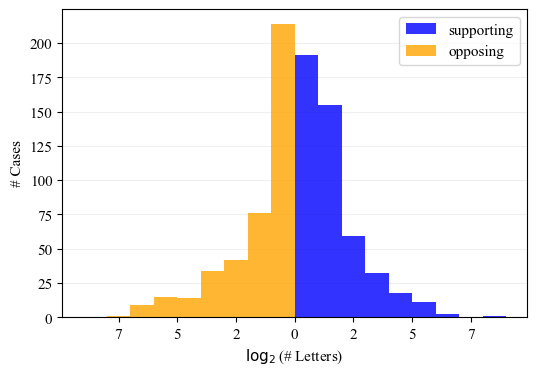

In [10]:
plt.figure(figsize=(6,4))
idx1 = df['n_support'] > 0
idx2 = df['n_oppose'] > 0
bins1 = np.arange(0, 10, 1)
bins2 = np.arange(-9, 1, 1)
plt.hist(np.log2(df.loc[idx1, 'n_support']), alpha=0.8, color='blue', label='supporting', bins=bins1)
plt.hist(-np.log2(df.loc[idx2, 'n_oppose']), alpha=0.8, color='orange', label='opposing', bins=bins2)
plt.xlabel(r'$\log_2$(# Letters)')
plt.ylabel('# Cases')
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.gca().set_axisbelow(True)
def custom_formatter(xval, pos):
    if xval<0:
        return f"{abs(int(xval))}"
    else:
        return f"{int(xval)}"
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(custom_formatter))
#plt.title("Distribution of Support and Opposition Letters by Project")
plt.savefig(os.path.join(LOCAL_PATH, 'figures', 'fig_support_oppose.pdf'), bbox_inches='tight')
plt.show()

tex = r"""
\begin{figure}[H]
\caption{Distribution of Number of Support and Opposition Letters} \label{fig_support_oppose}
\vspace{-0.5cm}
\begin{center}
\includegraphics[width=\textwidth]{figures/fig_support_oppose.pdf}
\end{center}
\vspace{-0.4cm}
{\footnotesize \textit{Note}: Shows distribution of the number of supporting and opposing letters across cases. Cases with zero support or oppose letters are not included in the figure. Note that one case can have multiple supporting \emph{and} opposing letters.}
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "figures", "fig_support_oppose.tex"), "w", encoding='utf-8') as f:
    f.write(tex)

In [11]:
# Suffix statistics

sfx_df = pd.read_csv(os.path.join(LOCAL_PATH, "intermediate_data/cpc", "suffix_groups.csv"))

text = "; ".join(sfx_df['group_desc'].unique().tolist())
text += "."
text = text.replace("&", "\\&")
with open(os.path.join(LOCAL_PATH, "results", "suffix_groups.tex"), "w") as f:
    f.write(text)

RESULTS = {
    "NumUniqueSuffixes": f"{sfx_df['suffix'].nunique():.0f}",
    "NumSfxGroups": f"{sfx_df['group'].nunique():.0f}"
}

_ = wt.update_results(RESULTS)

RESULTS

{'NumUniqueSuffixes': '77', 'NumSfxGroups': '15'}